# 划分数据集

In [ ]:
# import os
# from Bio import SeqIO

# # 生成替身序列，防止cdhit出毛病

# original_fasta_path = './data/local_features/cluster/original_fasta/'
# index_fasta_path = './data/local_features/cluster/index_fasta/'
# index_dict_path = './data/local_features/cluster/index_dict/'
# cluster_path = './data/local_features/cluster/cluster_out/'

# files = os.listdir(original_fasta_path)
# for file in files:
#     # 读取序列
#     with open(os.path.join(original_fasta_path, file), "r") as f:
#         sequences = SeqIO.parse(f, "fasta")
#         sequence_dict = {seq_record.id : seq_record.seq for seq_record in sequences}
    
#     # 生成替身序列，并记录替身字典
#     f = open(os.path.join(index_fasta_path, file), 'w')
#     f_dict = open(os.path.join(index_dict_path, file.replace('.fasta', '.dict')), 'w')
#     key_list = list(sequence_dict.keys())
#     for i in range(0,len(key_list)):
#         f_dict.write("seq{:05d}==={}\n".format(i, key_list[i]))
#         f.write(">seq{:05d}\n{}\n".format(i, sequence_dict[key_list[i]]))
#     f.close()
#     f_dict.close()

#     print(f"cdhit -c 0.7 -i {file} -o ../cluster_out/{file.replace('.fasta', '_cdhit.fasta')} -T 192 -M 20000")

# # 在/home/admin123/work/GTmining/data/local_features/cluster/index_fasta/下运行


cdhit -c 0.7 -i GT111_aln_check.fasta -o ../cluster_out/GT111_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT81_aln_check.fasta -o ../cluster_out/GT81_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT32_aln_check.fasta -o ../cluster_out/GT32_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT24_aln_check.fasta -o ../cluster_out/GT24_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT2_aln_check.fasta -o ../cluster_out/GT2_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT6_aln_check.fasta -o ../cluster_out/GT6_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT55_aln_check.fasta -o ../cluster_out/GT55_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT82_aln_check.fasta -o ../cluster_out/GT82_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT75_aln_check.fasta -o ../cluster_out/GT75_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT84_aln_check.fasta -o ../cluster_out/GT84_aln_check_cdhit.fasta -T 192 -M 20000
cdhit -c 0.7 -i GT62_a

In [ ]:
# # 采样获取训练集：测试集=9：1
# import os
# import pandas as pd
# import random
# from tqdm import tqdm

# cluster_path = './data/local_features/cluster/cluster_out/'
# index_dict_path = './data/local_features/cluster/index_dict/'
# real_test = ['GT7', 'GT25', 'GT55', 'GT64', 'GT81', 'GT82']

# files = [x for x in os.listdir(cluster_path) if x.endswith('.clstr')]

# activate_index = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
#                   'UDP-Gal': 3, 'UDP-GalNAc': 4,
#                   'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
#                   'dTDP-Rha': 8, 'Other': 9}

# cluster_dict = {x : [] for x in activate_index.keys()}

# # 获取活性标签
# df = pd.read_excel('./data/cazy_annot_domain/纯纯GT-A_有NDP-Sugar活性注释.xlsx')
# activate_dict = {}
# for i in range(0,df.shape[0]):
#     if '[' in df['NDP-Sugar活性'][i]:
#         activate_dict[df['Family'][i]+'_'+df['GenBank'][i]] = 'Other'
#     else:
#         activate_dict[df['Family'][i]+'_'+df['GenBank'][i]] = df['NDP-Sugar活性'][i]

# # 读取cluster文件
# for file in files:
#     # 读取index文件
#     index_dict = {}
#     with open(os.path.join(index_dict_path, file.replace('_cdhit.fasta.clstr', '.dict')), 'r')as f:
#         for line in f:
#             line = line.strip().split('===')
#             index_dict[line[0]] = line[1]
#     # 转译cluster文件
#     file = os.path.join(cluster_path, file)
#     clusters = {}
#     with open(file, 'r') as file:
#         current_cluster = None
#         for line in file:
#             line = line.strip()
#             if line.startswith('>Cluster'):
#                 # 新的cluster开始
#                 cluster_number = 'Cluster_' + line.split()[1]
#                 current_cluster = cluster_number
#                 clusters[current_cluster] = []
#             elif line and current_cluster is not None:
#                 # 这一行包含序列信息
#                 seq_name = line.split(', >')[1].split('... ')[0]
#                 clusters[current_cluster].append(index_dict[seq_name])
    
#     # 检查cluster中活性数据是否冲突
#     for _, cluster_list in clusters.items():
#         cluster_activate = [activate_dict[x] for x in cluster_list]
#         cluster_activate = list(set(cluster_activate))
#         if len(cluster_activate) > 2:
#             print('┗|｀O′|┛ 嗷~~，发现有的簇花心了！')

#     # 写入活性cluter字典
#     for _, cluster_list in clusters.items():
#         cluster_dict[activate_dict[cluster_list[0]]].append([x for x in cluster_list])



# fold_num = 1
# while fold_num <= 10:
#     # ==================== 划分训练集、测试集 ====================
#     df = pd.DataFrame(columns=['Family', 'GenBank', 'Cluster_GenBank_Random', 'Activate', 'Dataset'])

#     for temp_key, temp_value in cluster_dict.items():
#         # 写入realtest
#         new_value = []
#         realtest_value = []
#         for cluster in temp_value:
#             if cluster[0].split('_')[0] in real_test:
#                 realtest_value.append(cluster)
#             else:
#                 new_value.append(cluster)
#         temp_value = new_value
#         realtest_samples = realtest_value
#         # 处理realtest
#         for samples in tqdm(realtest_samples, desc=temp_key):
#             sample_family = samples[0].split('_')[0]
#             for sample in samples:
#                 df.loc[len(df)] = [sample_family, sample, samples[0], activate_dict[sample], 'realtest']


#         # 计算各集合的目标范围（总样本数的±5%）
#         total_samples = sum(len(c) for c in temp_value)
#         train_min = 0.85 * total_samples
#         train_max = 0.95 * total_samples
#         test_min = 0.05 * total_samples
#         test_max = 0.15 * total_samples

#         total_attempts = 0
#         while total_attempts < 9:
#             # 随机打乱簇的顺序，之后就可以直接遍历而无需采样
#             shuffled = random.sample(temp_value, len(temp_value))
            
#             # 初始化集合
#             train, test = [], []
#             t_size, te_size = 0, 0
            
#             for cluster in shuffled:
#                 c_size = len(cluster)
#                 candidates = []
                
#                 # 确定可加入的集合
#                 if te_size + c_size <= test_max:
#                     candidates.append('test')
#                 if t_size + c_size <= train_max:
#                     candidates.append('train')
                
#                 if not candidates:
#                     break  # 无法分配，本次尝试失败
                
#                 # 优先填充未达最小值的集合
#                 priorities = []
#                 for candidate in candidates:
#                     current = {'train': t_size, 'test': te_size}[candidate]
#                     min_req = {'train': train_min, 'test': test_min}[candidate]
#                     priority = min_req - current if current < min_req else 0
#                     priorities.append((priority, candidate))
                
#                 # 选择最需要填充的集合
#                 priorities.sort(reverse=True, key=lambda x: x[0])
#                 chosen = priorities[0][1]
                
#                 # 分配簇
#                 if chosen == 'train':
#                     train.append(cluster)
#                     t_size += c_size
#                 elif chosen == 'test':
#                     test.append(cluster)
#                     te_size += c_size

            
#             # 验证分配结果
#             if (train_min <= t_size <= train_max and
#                 test_min <= te_size <= test_max and
#                 (t_size + te_size) == total_samples):
#                 # 展开簇中的样本
#                 train_samples = train
#                 test_samples = test
#                 break
            
#             total_attempts += 1

#         if total_attempts >= 9:
#             print(f"error in {temp_key}")
        
#         for samples in tqdm(train_samples, desc=temp_key + ' train'):
#             sample_family = samples[0].split('_')[0]
#             for sample in samples:
#                 df.loc[len(df)] = [sample_family, sample, samples[0], activate_dict[sample], 'train']
#         for samples in tqdm(test_samples, desc=temp_key + ' test'):
#             sample_family = samples[0].split('_')[0]
#             for sample in samples:
#                 df.loc[len(df)] = [sample_family, sample, samples[0], activate_dict[sample], 'test']
        
#         # break
        
#     df = df.drop_duplicates()
#     df.reset_index(drop=True, inplace=True)

#     split_name = [df['Activate'][i] + '_' + df['Dataset'][i] for i in range(0, df.shape[0])]
#     if not len(list(set(split_name))) == 28:
#         print('========== ┗|｀O′|┛ 嗷~~，分类中有类缺失！ ==========')
#     else:
#         print('========== 分类中没有类缺失！ ==========')
#         df.to_excel(f'./data/local_features/cluster/dataseat_split_{fold_num}.xlsx', index=False)
#         fold_num += 1

# 提取全局特征

In [ ]:
# # 提取局部结构特征第一步
# import os

# structure_path = './data/cazy_annot_domain/domain/'
# folders = os.listdir(structure_path)

# f = open('./Protein_extract_feature_step1.sh', 'w')
# for folder in folders:
#     directory = os.path.join(structure_path, folder)
#     files = os.listdir(directory)
#     for file in files:
#         f.write(f"python ./Extract_feature_step1.py {file} {folder} 6 6\n")
# f.close()

# # nohup parallel --jobs 30 < Protein_extract_feature_step1.sh > Protein_align_1.out 2>&1 &


In [ ]:
# 对接底物Mn

# 在/home/admin123/work/starG/data/20240705_MaSIF_Dock_GNN/ddG/haveDXD/下面进行对接

# /home/admin123/software/mgltools_x86_64Linux2_1.5.7/bin/pythonsh /home/admin123/work/starG/script/AutodockVinaWork/prepare_receptor4.py -r ./cazy_cluster_center.pdb -v -o ./cazy_cluster_center.pdbqt -A checkhydrogens

# /home/admin123/software/autodock_vina/bin/vina --config ./cazy_cluster_center.txt

# 对接底物UDP-Gal

# 在/home/admin123/software/Le/下面进行对接

# /home/admin123/software/Le/ledock Le_dock_cazy.txt

In [ ]:
# # 提取局部结构特征第二步
# import os

# structure_path = './data/cazy_annot_domain/domain/'
# folders = os.listdir(structure_path)

# sample_redies_udp = 8.0
# sample_redies_sugar = 10.0

# step = 1
# epoch = 1
# f = open(f'./Extract_feature_step2_epoch{epoch}.sh', 'w')
# for folder in folders:
#     directory = os.path.join(structure_path, folder)
#     files = os.listdir(directory)
#     for file in files:
#         if step % 40 == 0:
#             f.write(f"taskset -c {step} python ./Extract_feature_step2.py {file} {folder} {sample_redies_udp} {sample_redies_sugar}\n")
#             f.close()
#             epoch += 1
#             f = open(f'./Extract_feature_step2_epoch{epoch}.sh', 'w')
#             step = 1
#             continue
#         f.write(f"taskset -c {step} python ./Extract_feature_step2.py {file} {folder} {sample_redies_udp} {sample_redies_sugar}\n")
#         step = step + 1
# f.close()

# f = open(f'./Extract_feature_step2_AAArun.sh', 'w')
# for e in range(epoch):
#     f.write(f"parallel --jobs 40 < Extract_feature_step2_epoch{e+1}.sh\n")
# f.close()

# # nohup bash Extract_feature_step2_AAArun.sh &


# 生成数据集

In [1]:
skip_list = ['GT2_AUV51559_1', 'GT2_QQN43717_1', 'GT2_BCZ64624_1', 'GT2_CAO99139_1', 'GT2_QQJ12945_1',
             'GT32_ABP35532_1', 'GT2_QIY47078_1', 'GT2_ATY61741_1', 'GT2_UXJ04752_1', 'GT2_QXH51152_1',
             'GT2_UXV20753_1', 'GT2_UQX61489_1', 'GT2_BBX21645_1', 'GT2_BBN74818_1', 'GT2_UAY64771_1',
             'GT2_XBN37388_1', 'GT2_AUZ44912_1', 'GT8_CAB4108102_1', 'GT8_ABF84224_1', 'GT84_UST55032_1']
skip_correspond_information_dict = {
    '1.25, 22.89, 14.67, 0.30, 0.00, -0.02, 0.62###-0.25, 15.41, 3.61, 0.62, 0.51, -0.02, -1.00###-1.08, 13.70, 9.15, -0.79, -0.02, -0.33, -0.78':'1.25, 22.89, 14.67, 0.30, 0.00, -0.02, 0.62###-0.25, 15.41, 3.61, 0.62, 0.51, -0.02, -1.00###-1.08, 13.70, 9.15, -0.79, -0.01, -0.33, -0.78'
}
skip_correspond_information = list(skip_correspond_information_dict.keys())

In [2]:
'''
根据DiffPool的教程，我需要准备的东西有4样，分别是A、graph_indicator、graph_labels、node_attributes
'''
import numpy as np
import os
from tqdm import tqdm
import shutil
import pandas as pd

sample_redies_udp = 6.0
sample_redies_sugar = 6.0

graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                    'UDP-Gal': 3, 'UDP-GalNAc': 4,
                    'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                    'dTDP-Rha': 8, 'Other': 9}

# 获取有哪些local结构
storage_path = './data/local_features/features/'
storage_path = os.path.join(storage_path, f"udp{sample_redies_udp}_sugar{sample_redies_sugar}")
dl_data_path = './data/local_features/dl_data/'
dl_data_path = os.path.join(dl_data_path, f"udp{sample_redies_udp}_sugar{sample_redies_sugar}")
folders = os.listdir(storage_path)
local_dict = {}
for folder in folders:
    npy_path = os.path.join(storage_path, folder)
    local_dict[folder.split('_')[0]] = [x.split('.npy')[0] for x in os.listdir(npy_path)]

# 获取活性标签
df = pd.read_excel('./data/cazy_annot_domain/纯纯GT-A_有NDP-Sugar活性注释.xlsx')
activate_dict = {}
for i in range(0,df.shape[0]):
    if '[' in df['NDP-Sugar活性'][i]:
        activate_dict[df['Family'][i]+'_'+df['GenBank'][i]] = 'Other'
    else:
        activate_dict[df['Family'][i]+'_'+df['GenBank'][i]] = df['NDP-Sugar活性'][i]

# 生成文件列表
process_path = {'train':[], 'test':[], 'realtest':[]}
df = pd.read_excel('./data/local_features/cluster/dataseat_split_1.xlsx')
for i in range(0,df.shape[0]):
    if df['GenBank'][i] in local_dict[df['Family'][i]]:
        if df['GenBank'][i] in skip_list:
            continue
        npy_path = os.path.join(storage_path, f"{df['Family'][i]}_aln_check")
        process_path[df['Dataset'][i]].append(os.path.join(npy_path, df['GenBank'][i]+'.npy'))
train_process_path = process_path['train']
test_process_path = process_path['test']
realtest_process_path = process_path['realtest']

# 管理文件夹
if not os.path.exists(dl_data_path):
    os.makedirs(dl_data_path)
else:
    shutil.rmtree(dl_data_path)
    os.makedirs(dl_data_path)
os.makedirs(f'{dl_data_path}/train/')
os.makedirs(f'{dl_data_path}/train/trace_file/')
os.makedirs(f'{dl_data_path}/test/')
os.makedirs(f'{dl_data_path}/test/trace_file/')
os.makedirs(f'{dl_data_path}/realtest/')
os.makedirs(f'{dl_data_path}/realtest/trace_file/')

# ==================== 生成数据 ====================
def make_database(process_path: list, data_type: str):
    f_A = open(f'{dl_data_path}/{data_type}/Rha_Finder_A.txt', 'w')
    f_graph_indicator = open(f'{dl_data_path}/{data_type}/Rha_Finder_graph_indicator.txt', 'w')
    f_graph_labels = open(f'{dl_data_path}/{data_type}/Rha_Finder_graph_labels.txt', 'w')
    f_node_attributes = open(f'{dl_data_path}/{data_type}/Rha_Finder_node_attributes.txt', 'w')
    f_correspond_information = open(f'{dl_data_path}/{data_type}/Predict_correspond_information.txt', 'w')
    edge_max = -1
    graph_idx = -1
    # 已经重构了数据处理部分，读取一次npy文件，写入四种不同的文件，提升I/O性能
    for file in tqdm(process_path):
        # +++++ 一次性读取npy文件 +++++
        try:
            input_dict = np.load(file, allow_pickle=True)
        except:
            print(f"wrong {file}")
            continue
        input_dict = input_dict[()]
        if len(input_dict['edges']) <= 100:
            # 用来检查不正确的局部网格
            print(f"error local feature in {file.split('/')[-1].split('.npy')[0]}")
            continue
        # +++++ f_A的数据处理 +++++
        edges = input_dict['edges']
        edges += (edge_max +1)
        for edge in edges:
            f_A.write(f"{edge[0]}, {edge[1]}\n")
        edge_max = np.max(edges)
        # +++++ f_graph_indicator的数据处理 +++++
        graph_idx += 1
        xyzs = input_dict['xyz']
        for i in range(0, xyzs.shape[0]):
            f_graph_indicator.write(f"{graph_idx}\n")
        # +++++ f_graph_labels的数据处理 +++++
        group_name = file.split('/')[-1].split('.npy')[0]
        f_graph_labels.write(f"{graph_label_dict[activate_dict[group_name]]}\n")
        # +++++ f_node_attributes的数据处理 +++++
        xyzs = input_dict['xyz']
        sis = input_dict['si']
        hbonds = input_dict['hbond']
        charges = input_dict['charge']
        hphobs = input_dict['hphob']
        trace_temp = file.split('/')[-1] + f'==={edge_max}.txt'
        f_trace_file = open(f'{dl_data_path}/{data_type}/trace_file/{trace_temp}', 'w')
        for i in range(0, xyzs.shape[0]):
            # x = xyzs[i][0] + np.random.normal(loc=0, scale=0.75)
            # y = xyzs[i][1] + np.random.normal(loc=0, scale=0.75)
            # z = xyzs[i][2] + np.random.normal(loc=0, scale=0.75)
            x = xyzs[i][0]
            y = xyzs[i][1]
            z = xyzs[i][2]
            f_trace_file.write("{:>10.6f}, {:>10.6f}, {:>10.6f}\n".format(x, y, z))
            f_node_attributes.write("{:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}\n".format(x, y, z, sis[i][0], hbonds[i][0], charges[i][0], hphobs[i][0]))
        f_trace_file.close()
        f_correspond_information.write(file.split('/')[-1].split('.npy')[0] + '===')
        temp_correspond_information = ''
        temp_correspond_information = temp_correspond_information + "{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(xyzs[0][0], 5),
                                                                                                              round(xyzs[0][1], 5),
                                                                                                              round(xyzs[0][2], 5),
                                                                                                              round(sis[0][0], 5),
                                                                                                              round(hbonds[0][0], 5),
                                                                                                              round(charges[0][0], 5),
                                                                                                              round(hphobs[0][0], 5))
        temp_correspond_information = temp_correspond_information + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(xyzs[1][0], 5),
                                                                                                                 round(xyzs[1][1], 5),
                                                                                                                 round(xyzs[1][2], 5),
                                                                                                                 round(sis[1][0], 5),
                                                                                                                 round(hbonds[1][0], 5),
                                                                                                                 round(charges[1][0], 5),
                                                                                                                 round(hphobs[1][0], 5))
        temp_correspond_information = temp_correspond_information + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}\n".format(round(xyzs[2][0], 5),
                                                                                                                   round(xyzs[2][1], 5),
                                                                                                                   round(xyzs[2][2], 5),
                                                                                                                   round(sis[2][0], 5),
                                                                                                                   round(hbonds[2][0], 5),
                                                                                                                   round(charges[2][0], 5),
                                                                                                                   round(hphobs[2][0], 5))
        if temp_correspond_information in skip_correspond_information:
            temp_correspond_information = skip_correspond_information_dict[temp_correspond_information]
        f_correspond_information.write(temp_correspond_information)

    f_A.close()
    f_graph_indicator.close()
    f_graph_labels.close()
    f_node_attributes.close()
    f_correspond_information.close()

make_database(train_process_path, 'train')
make_database(test_process_path, 'test')
make_database(realtest_process_path, 'realtest')

100%|██████████| 491/491 [00:03<00:00, 125.20it/s]


# 生成数据集（排除NaN的数据）

In [2]:
skip_list = ['GT2_AUV51559_1', 'GT2_QQN43717_1', 'GT2_BCZ64624_1', 'GT2_CAO99139_1', 'GT2_QQJ12945_1',
             'GT32_ABP35532_1', 'GT2_QIY47078_1', 'GT2_ATY61741_1', 'GT2_UXJ04752_1', 'GT2_QXH51152_1',
             'GT2_UXV20753_1', 'GT2_UQX61489_1', 'GT2_BBX21645_1', 'GT2_BBN74818_1', 'GT2_UAY64771_1',
             'GT2_XBN37388_1', 'GT2_AUZ44912_1', 'GT8_CAB4108102_1', 'GT8_ABF84224_1', 'GT84_UST55032_1']
skip_correspond_information_dict = {
    '1.25, 22.89, 14.67, 0.30, 0.00, -0.02, 0.62###-0.25, 15.41, 3.61, 0.62, 0.51, -0.02, -1.00###-1.08, 13.70, 9.15, -0.79, -0.02, -0.33, -0.78':'1.25, 22.89, 14.67, 0.30, 0.00, -0.02, 0.62###-0.25, 15.41, 3.61, 0.62, 0.51, -0.02, -1.00###-1.08, 13.70, 9.15, -0.79, -0.01, -0.33, -0.78'
}
skip_correspond_information = list(skip_correspond_information_dict.keys())

In [11]:
'''
根据DiffPool的教程，我需要准备的东西有4样，分别是A、graph_indicator、graph_labels、node_attributes
'''
import numpy as np
import os
from tqdm import tqdm
import shutil
import pandas as pd

sample_redies_udp = 10.0
sample_redies_sugar = 10.0

graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                    'UDP-Gal': 3, 'UDP-GalNAc': 4,
                    'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                    'dTDP-Rha': 8, 'Other': 9}

for fold_num in range(1, 11):
    # 获取有哪些local结构
    storage_path = './data/local_features/features/'
    storage_path = os.path.join(storage_path, f"udp{sample_redies_udp}_sugar{sample_redies_sugar}")
    dl_data_path = './data/local_features/dl_data_final/'
    dl_data_path = os.path.join(dl_data_path, f"udp{sample_redies_udp}_sugar{sample_redies_sugar}_fold{fold_num}")
    folders = os.listdir(storage_path)
    local_dict = {}
    for folder in folders:
        npy_path = os.path.join(storage_path, folder)
        local_dict[folder.split('_')[0]] = [x.split('.npy')[0] for x in os.listdir(npy_path)]

    # 获取活性标签
    df = pd.read_excel('./data/cazy_annot_domain/纯纯GT-A_有NDP-Sugar活性注释.xlsx')
    activate_dict = {}
    for i in range(0,df.shape[0]):
        if '[' in df['NDP-Sugar活性'][i]:
            activate_dict[df['Family'][i]+'_'+df['GenBank'][i]] = 'Other'
        else:
            activate_dict[df['Family'][i]+'_'+df['GenBank'][i]] = df['NDP-Sugar活性'][i]

    # 生成文件列表
    process_path = {'train':[], 'test':[], 'realtest':[]}
    df = pd.read_excel(f'./data/local_features/cluster/dataseat_split_{fold_num}.xlsx')
    for i in range(0,df.shape[0]):
        if df['GenBank'][i] in local_dict[df['Family'][i]]:
            if df['GenBank'][i] in skip_list:
                continue
            npy_path = os.path.join(storage_path, f"{df['Family'][i]}_aln_check")
            process_path[df['Dataset'][i]].append(os.path.join(npy_path, df['GenBank'][i]+'.npy'))
    train_process_path = process_path['train']
    test_process_path = process_path['test']
    realtest_process_path = process_path['realtest']

    # 管理文件夹
    if not os.path.exists(dl_data_path):
        os.makedirs(dl_data_path)
    else:
        shutil.rmtree(dl_data_path)
        os.makedirs(dl_data_path)
    os.makedirs(f'{dl_data_path}/train/')
    os.makedirs(f'{dl_data_path}/train/trace_file/')
    os.makedirs(f'{dl_data_path}/test/')
    os.makedirs(f'{dl_data_path}/test/trace_file/')
    os.makedirs(f'{dl_data_path}/realtest/')
    os.makedirs(f'{dl_data_path}/realtest/trace_file/')

    # ==================== 生成数据 ====================
    def make_database(process_path: list, data_type: str):
        f_A = open(f'{dl_data_path}/{data_type}/Rha_Finder_A.txt', 'w')
        f_graph_indicator = open(f'{dl_data_path}/{data_type}/Rha_Finder_graph_indicator.txt', 'w')
        f_graph_labels = open(f'{dl_data_path}/{data_type}/Rha_Finder_graph_labels.txt', 'w')
        f_node_attributes = open(f'{dl_data_path}/{data_type}/Rha_Finder_node_attributes.txt', 'w')
        f_correspond_information = open(f'{dl_data_path}/{data_type}/Predict_correspond_information.txt', 'w')
        edge_max = -1
        graph_idx = -1
        # 已经重构了数据处理部分，读取一次npy文件，写入四种不同的文件，提升I/O性能
        for file in tqdm(process_path):
            # +++++ 一次性读取npy文件 +++++
            try:
                input_dict = np.load(file, allow_pickle=True)
            except:
                print(f"wrong {file}")
                continue
            input_dict = input_dict[()]
            if len(input_dict['edges']) <= 100:
                # 用来检查不正确的局部网格
                print(f"error local feature in {file.split('/')[-1].split('.npy')[0]}")
                continue
            # +++++ f_A的数据处理 +++++
            edges = input_dict['edges']
            edges += (edge_max +1)
            for edge in edges:
                f_A.write(f"{edge[0]}, {edge[1]}\n")
            edge_max = np.max(edges)
            # +++++ f_graph_indicator的数据处理 +++++
            graph_idx += 1
            xyzs = input_dict['xyz']
            for i in range(0, xyzs.shape[0]):
                f_graph_indicator.write(f"{graph_idx}\n")
            # +++++ f_graph_labels的数据处理 +++++
            group_name = file.split('/')[-1].split('.npy')[0]
            f_graph_labels.write(f"{graph_label_dict[activate_dict[group_name]]}\n")
            # +++++ f_node_attributes的数据处理 +++++
            xyzs = input_dict['xyz']
            sis = input_dict['si']
            hbonds = input_dict['hbond']
            charges = input_dict['charge']
            hphobs = input_dict['hphob']
            trace_temp = file.split('/')[-1] + f'==={edge_max}.txt'
            f_trace_file = open(f'{dl_data_path}/{data_type}/trace_file/{trace_temp}', 'w')
            for i in range(0, xyzs.shape[0]):
                # x = xyzs[i][0] + np.random.normal(loc=0, scale=0.75)
                # y = xyzs[i][1] + np.random.normal(loc=0, scale=0.75)
                # z = xyzs[i][2] + np.random.normal(loc=0, scale=0.75)
                x = xyzs[i][0]
                y = xyzs[i][1]
                z = xyzs[i][2]
                f_trace_file.write("{:>10.6f}, {:>10.6f}, {:>10.6f}\n".format(x, y, z))
                f_node_attributes.write("{:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}\n".format(x, y, z, sis[i][0], hbonds[i][0], charges[i][0], hphobs[i][0]))
            f_trace_file.close()
            f_correspond_information.write(file.split('/')[-1].split('.npy')[0] + '===')
            temp_correspond_information = ''
            temp_correspond_information = temp_correspond_information + "{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(xyzs[0][0], 5),
                                                                                                                round(xyzs[0][1], 5),
                                                                                                                round(xyzs[0][2], 5),
                                                                                                                round(sis[0][0], 5),
                                                                                                                round(hbonds[0][0], 5),
                                                                                                                round(charges[0][0], 5),
                                                                                                                round(hphobs[0][0], 5))
            temp_correspond_information = temp_correspond_information + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(xyzs[1][0], 5),
                                                                                                                    round(xyzs[1][1], 5),
                                                                                                                    round(xyzs[1][2], 5),
                                                                                                                    round(sis[1][0], 5),
                                                                                                                    round(hbonds[1][0], 5),
                                                                                                                    round(charges[1][0], 5),
                                                                                                                    round(hphobs[1][0], 5))
            temp_correspond_information = temp_correspond_information + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}\n".format(round(xyzs[2][0], 5),
                                                                                                                    round(xyzs[2][1], 5),
                                                                                                                    round(xyzs[2][2], 5),
                                                                                                                    round(sis[2][0], 5),
                                                                                                                    round(hbonds[2][0], 5),
                                                                                                                    round(charges[2][0], 5),
                                                                                                                    round(hphobs[2][0], 5))
            if temp_correspond_information in skip_correspond_information:
                temp_correspond_information = skip_correspond_information_dict[temp_correspond_information]
            f_correspond_information.write(temp_correspond_information)

        f_A.close()
        f_graph_indicator.close()
        f_graph_labels.close()
        f_node_attributes.close()
        f_correspond_information.close()

    make_database(train_process_path, 'train')
    make_database(test_process_path, 'test')
    make_database(realtest_process_path, 'realtest')

100%|██████████| 491/491 [00:05<00:00, 93.60it/s] 


# 废物
- 生成数据集（排除NaN的数据）对于小于3个的增强到3个，大于3个的不管

In [ ]:
# '''
# 根据DiffPool的教程，我需要准备的东西有4样，分别是A、graph_indicator、graph_labels、node_attributes
# '''
# import numpy as np
# import os
# from tqdm import tqdm
# import shutil
# import pandas as pd

# sample_redies_udp = 6.1
# sample_redies_sugar = 6.1
# skip_dict = {'train' : ['GT2_UXJ04752_1', 'GT2_QIY47078_1', 'GT2_BBN74818_1', 'GT32_ABP35532_1', 'GT2_XBN37388_1',
#                         'GT2_UAY64771_1', 'GT2_UQX61489_1', 'GT2_UXV20753_1', 'GT2_AUZ44912_1', 'GT2_ATY61741_1',
#                         'GT2_QQJ12945_1', 'GT2_QXH51152_1', 'GT2_CAO99139_1'],
#              'val' : ['GT2_BBX21645_1', 'GT2_BCZ64624_1'],
#              'test' : [],
#              'realtest' : []}

# graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
#                     'UDP-Gal': 3, 'UDP-GalNAc': 4,
#                     'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
#                     'dTDP-Rha': 8, 'Other': 9}

# # 获取有哪些local结构
# storage_path = './data/local_features/features/'
# storage_path = os.path.join(storage_path, f"udp{sample_redies_udp}_sugar{sample_redies_sugar}")
# dl_data_path = './data/local_features/dl_data/'
# dl_data_path = os.path.join(dl_data_path, f"udp{sample_redies_udp}_sugar{sample_redies_sugar}")
# folders = os.listdir(storage_path)
# local_dict = {}
# for folder in folders:
#     npy_path = os.path.join(storage_path, folder)
#     local_dict[folder.split('_')[0]] = [x.split('.npy')[0] for x in os.listdir(npy_path)]

# # 获取活性标签
# df = pd.read_excel('./data/cazy_annot_domain/纯纯GT-A_有NDP-Sugar活性注释.xlsx')
# activate_dict = {}
# for i in range(0,df.shape[0]):
#     if '[' in df['NDP-Sugar活性'][i]:
#         activate_dict[df['Family'][i]+'_'+df['GenBank'][i]] = 'Other'
#     else:
#         activate_dict[df['Family'][i]+'_'+df['GenBank'][i]] = df['NDP-Sugar活性'][i]

# # 生成文件列表
# process_path = {'train':[], 'val':[], 'test':[], 'realtest':[]}
# df = pd.read_excel('./data/local_features/cluster/dataseat_split.xlsx')
# for _, group_df in df.groupby('Cluster_GenBank_Random'):
#     group_df.reset_index(drop=True, inplace=True)
#     if group_df.shape[0] < 3:
#         cc = 0
#         for i in range(0,group_df.shape[0]):
#             if group_df['GenBank'][i] in local_dict[group_df['Family'][i]]:
#                 if group_df['GenBank'][i] in skip_dict[group_df['Dataset'][i]]:
#                     continue
#                 npy_path = os.path.join(storage_path, f"{group_df['Family'][i]}_aln_check")
#                 process_path[group_df['Dataset'][i]].append(os.path.join(npy_path, group_df['GenBank'][i]+'.npy'))
#                 cc += 1
#         if cc == 0:
#             continue
#         elif cc == 1:
#             for i in range(0,group_df.shape[0]):
#                 if group_df['GenBank'][i] in local_dict[group_df['Family'][i]]:
#                     if group_df['GenBank'][i] in skip_dict[group_df['Dataset'][i]]:
#                         continue
#                     npy_path = os.path.join(storage_path, f"{group_df['Family'][i]}_aln_check")
#                     process_path[group_df['Dataset'][i]].append(os.path.join(npy_path, group_df['GenBank'][i]+'.npy_ENHANCE'))
#                     process_path[group_df['Dataset'][i]].append(os.path.join(npy_path, group_df['GenBank'][i]+'.npy_ENHANCE'))
#         elif cc == 2:
#             for i in range(0,group_df.shape[0]):
#                 if group_df['GenBank'][i] in local_dict[group_df['Family'][i]]:
#                     if group_df['GenBank'][i] in skip_dict[group_df['Dataset'][i]]:
#                         continue
#                     npy_path = os.path.join(storage_path, f"{group_df['Family'][i]}_aln_check")
#                     process_path[group_df['Dataset'][i]].append(os.path.join(npy_path, group_df['GenBank'][i]+'.npy_ENHANCE'))
#     else:
#         for i in range(0,group_df.shape[0]):
#             if group_df['GenBank'][i] in local_dict[group_df['Family'][i]]:
#                 if group_df['GenBank'][i] in skip_dict[group_df['Dataset'][i]]:
#                     continue
#                 npy_path = os.path.join(storage_path, f"{group_df['Family'][i]}_aln_check")
#                 process_path[group_df['Dataset'][i]].append(os.path.join(npy_path, group_df['GenBank'][i]+'.npy'))
# train_process_path = process_path['train']
# val_process_path = process_path['val']
# test_process_path = process_path['test']
# realtest_process_path = process_path['realtest']

# # 管理文件夹
# if not os.path.exists(dl_data_path):
#     os.makedirs(dl_data_path)
# else:
#     shutil.rmtree(dl_data_path)
#     os.makedirs(dl_data_path)
# os.makedirs(f'{dl_data_path}/train/')
# os.makedirs(f'{dl_data_path}/train/trace_file/')
# os.makedirs(f'{dl_data_path}/val/')
# os.makedirs(f'{dl_data_path}/val/trace_file/')
# os.makedirs(f'{dl_data_path}/test/')
# os.makedirs(f'{dl_data_path}/test/trace_file/')
# os.makedirs(f'{dl_data_path}/realtest/')
# os.makedirs(f'{dl_data_path}/realtest/trace_file/')

# # ==================== 生成数据 ====================
# def make_database(process_path: list, data_type: str):
#     f_A = open(f'{dl_data_path}/{data_type}/Rha_Finder_A.txt', 'w')
#     f_graph_indicator = open(f'{dl_data_path}/{data_type}/Rha_Finder_graph_indicator.txt', 'w')
#     f_graph_labels = open(f'{dl_data_path}/{data_type}/Rha_Finder_graph_labels.txt', 'w')
#     f_node_attributes = open(f'{dl_data_path}/{data_type}/Rha_Finder_node_attributes.txt', 'w')
#     f_correspond_information = open(f'{dl_data_path}/{data_type}/Predict_correspond_information.txt', 'w')
#     edge_max = -1
#     graph_idx = -1
#     # 已经重构了数据处理部分，读取一次npy文件，写入四种不同的文件，提升I/O性能
#     for file in tqdm(process_path):
#         if file.endswith('.npy_ENHANCE'):
#             enhance_flag = True
#             file = file.split('.npy_ENHANCE')[0] + '.npy'
#         else:
#             enhance_flag = False
#         # +++++ 一次性读取npy文件 +++++
#         try:
#             input_dict = np.load(file, allow_pickle=True)
#         except:
#             print(f"wrong {file}")
#             continue
#         input_dict = input_dict[()]
#         if len(input_dict['edges']) <= 100:
#             # 用来检查不正确的局部网格
#             print(f"error local feature in {file.split('/')[-1].split('.npy')[0]}")
#             continue
#         # +++++ f_A的数据处理 +++++
#         edges = input_dict['edges']
#         edges += (edge_max +1)
#         for edge in edges:
#             f_A.write(f"{edge[0]}, {edge[1]}\n")
#         edge_max = np.max(edges)
#         # +++++ f_graph_indicator的数据处理 +++++
#         graph_idx += 1
#         xyzs = input_dict['xyz']
#         for i in range(0, xyzs.shape[0]):
#             f_graph_indicator.write(f"{graph_idx}\n")
#         # +++++ f_graph_labels的数据处理 +++++
#         group_name = file.split('/')[-1].split('.npy')[0]
#         f_graph_labels.write(f"{graph_label_dict[activate_dict[group_name]]}\n")
#         # +++++ f_node_attributes的数据处理 +++++
#         xyzs = input_dict['xyz']
#         sis = input_dict['si']
#         hbonds = input_dict['hbond']
#         charges = input_dict['charge']
#         hphobs = input_dict['hphob']
#         trace_temp = file.split('/')[-1] + f'==={edge_max}.txt'
#         f_trace_file = open(f'{dl_data_path}/{data_type}/trace_file/{trace_temp}', 'w')
#         information_cc = 0
#         for i in range(0, xyzs.shape[0]):
#             if enhance_flag:
#                 x = xyzs[i][0] + np.random.normal(loc=0, scale=0.75)
#                 y = xyzs[i][1] + np.random.normal(loc=0, scale=0.75)
#                 z = xyzs[i][2] + np.random.normal(loc=0, scale=0.75)
#             else:
#                 x = xyzs[i][0]
#                 y = xyzs[i][1]
#                 z = xyzs[i][2]
#             if information_cc < 3:
#                 information_cc += 1
#                 if information_cc == 1:
#                     f_correspond_information.write(file.split('/')[-1].split('.npy')[0] + '===')
#                     f_correspond_information.write("{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(x, 5),
#                                                                                                                           round(y, 5),
#                                                                                                                           round(z, 5),
#                                                                                                                           round(sis[0][0], 5),
#                                                                                                                           round(hbonds[0][0], 5),
#                                                                                                                           round(charges[0][0], 5),
#                                                                                                                           round(hphobs[0][0], 5)))
#                 elif information_cc == 2:
#                     f_correspond_information.write("###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(x, 5),
#                                                                                                                              round(y, 5),
#                                                                                                                              round(z, 5),
#                                                                                                                              round(sis[1][0], 5),
#                                                                                                                              round(hbonds[1][0], 5),
#                                                                                                                              round(charges[1][0], 5),
#                                                                                                                              round(hphobs[1][0], 5)))
#                 elif information_cc == 3:
#                     f_correspond_information.write("###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}\n".format(round(x, 5),
#                                                                                                                                round(y, 5),
#                                                                                                                                round(z, 5),
#                                                                                                                                round(sis[2][0], 5),
#                                                                                                                                round(hbonds[2][0], 5),
#                                                                                                                                round(charges[2][0], 5),
#                                                                                                                                round(hphobs[2][0], 5)))
#             f_trace_file.write("{:>10.6f}, {:>10.6f}, {:>10.6f}\n".format(x, y, z))
#             f_node_attributes.write("{:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}, {:>10.6f}\n".format(x, y, z, sis[i][0], hbonds[i][0], charges[i][0], hphobs[i][0]))
#         f_trace_file.close()

#     f_A.close()
#     f_graph_indicator.close()
#     f_graph_labels.close()
#     f_node_attributes.close()
#     f_correspond_information.close()

# make_database(train_process_path, 'train')
# make_database(val_process_path, 'val')
# make_database(test_process_path, 'test')
# make_database(realtest_process_path, 'realtest')

 44%|████▎     | 4576/10478 [00:28<00:31, 185.54it/s]

error local feature in GT2_AUV51559_1
error local feature in GT2_QQN43717_1


100%|██████████| 407/407 [00:03<00:00, 123.00it/s]


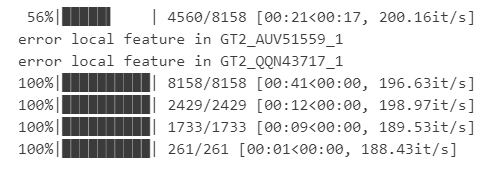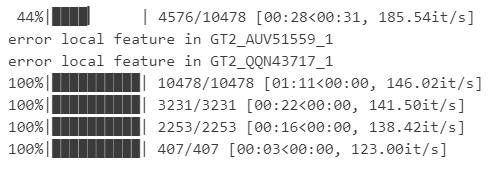